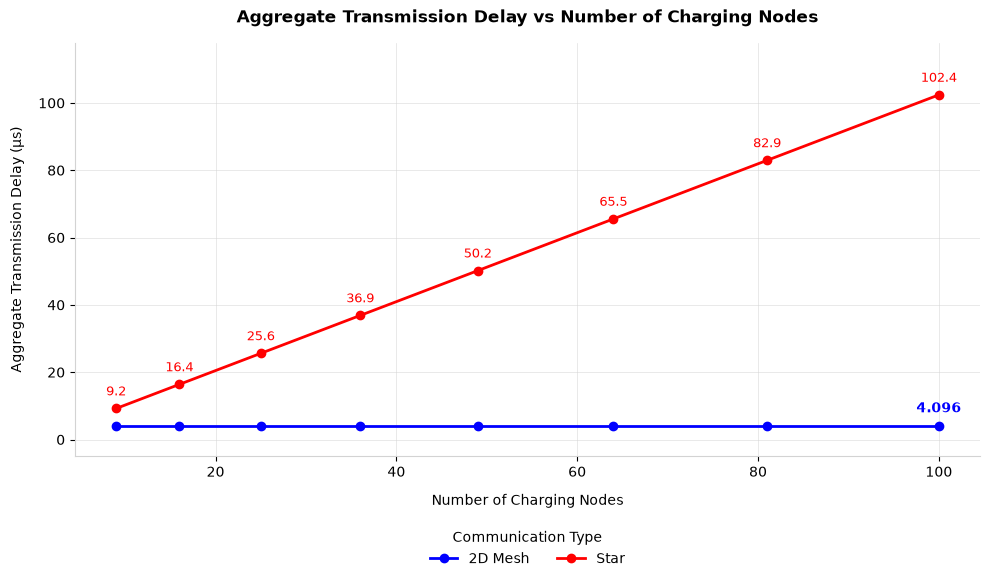

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Task 3(a) - Graph 1
# Increasing number of charging nodes
# Base Stations = 1
# ============================================================

# -----------------------------
# Network parameters
# -----------------------------
message_size_bytes = 64
bandwidth_bps = 1e9

# Transmission delay of one packet
packet_delay_us = (message_size_bytes * 8 / bandwidth_bps) * 1e6

# One request + one reply
request_reply_us = 2 * packet_delay_us

# -----------------------------
# Mesh sizes: 3x3 to 10x10
# -----------------------------
grid_size = np.arange(3, 11)

data = pd.DataFrame({
    'grid': [f"{g}x{g}" for g in grid_size],
    'nodes': grid_size**2
})

# ============================================================
# Calculations (Restored from your previous logic)
# ============================================================
# 2D Mesh: Max 4 neighbours * 2 (request+reply) * packet_delay
data['mesh_delay_us'] = 4 * 2 * packet_delay_us

# Star (Base Station): N nodes * 2 (request+reply) * packet_delay
data['base_station_delay_us'] = data['nodes'] * request_reply_us

# ============================================================
# Plot
# ============================================================
# Set figure size and style similar to theme_minimal()
plt.figure(figsize=(10, 6))
plt.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)
plt.gca().set_facecolor('white')

# 1. 2-D Mesh line (Blue)
plt.plot(data['nodes'], data['mesh_delay_us'], 
         color='blue', linewidth=2, marker='o', markersize=6, label='2D Mesh')

# Add time label to the LAST point of 2-D Mesh line
last_row = data.iloc[-1]
plt.text(last_row['nodes'], last_row['mesh_delay_us'] + 3, # +3 for vertical offset (vjust)
         f"{last_row['mesh_delay_us']:.3f}", 
         color='blue', fontweight='bold', ha='center', va='bottom', fontsize=10)

# 2. Base Station line (Red)
plt.plot(data['nodes'], data['base_station_delay_us'], 
         color='red', linewidth=2, marker='o', markersize=6, label='Star')

# Add time labels to ALL points of Base Station line
for _, row in data.iterrows():
    plt.text(row['nodes'], row['base_station_delay_us'] + 3, # +3 for vertical offset
             f"{row['base_station_delay_us']:.1f}", 
             color='red', ha='center', va='bottom', fontsize=9)

# -----------------------------
# Formatting and Labels
# -----------------------------
# Expand Y axis slightly (approx +15% of max value) so top labels don't get cut off
plt.ylim(-5, data['base_station_delay_us'].max() * 1.15)

plt.title("Aggregate Transmission Delay vs Number of Charging Nodes", fontweight='bold', pad=15)
plt.xlabel("Number of Charging Nodes", labelpad=10)
plt.ylabel("Aggregate Transmission Delay (μs)", labelpad=10)

# Configure Legend to sit at the bottom like ggplot's legend.position="bottom"
plt.legend(title="Communication Type", loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Remove top and right spines for that minimal look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('lightgray')
plt.gca().spines['bottom'].set_color('lightgray')

plt.tight_layout()

plt.savefig('graph1_transmission_delay.png', dpi=300, bbox_inches='tight')
plt.show()

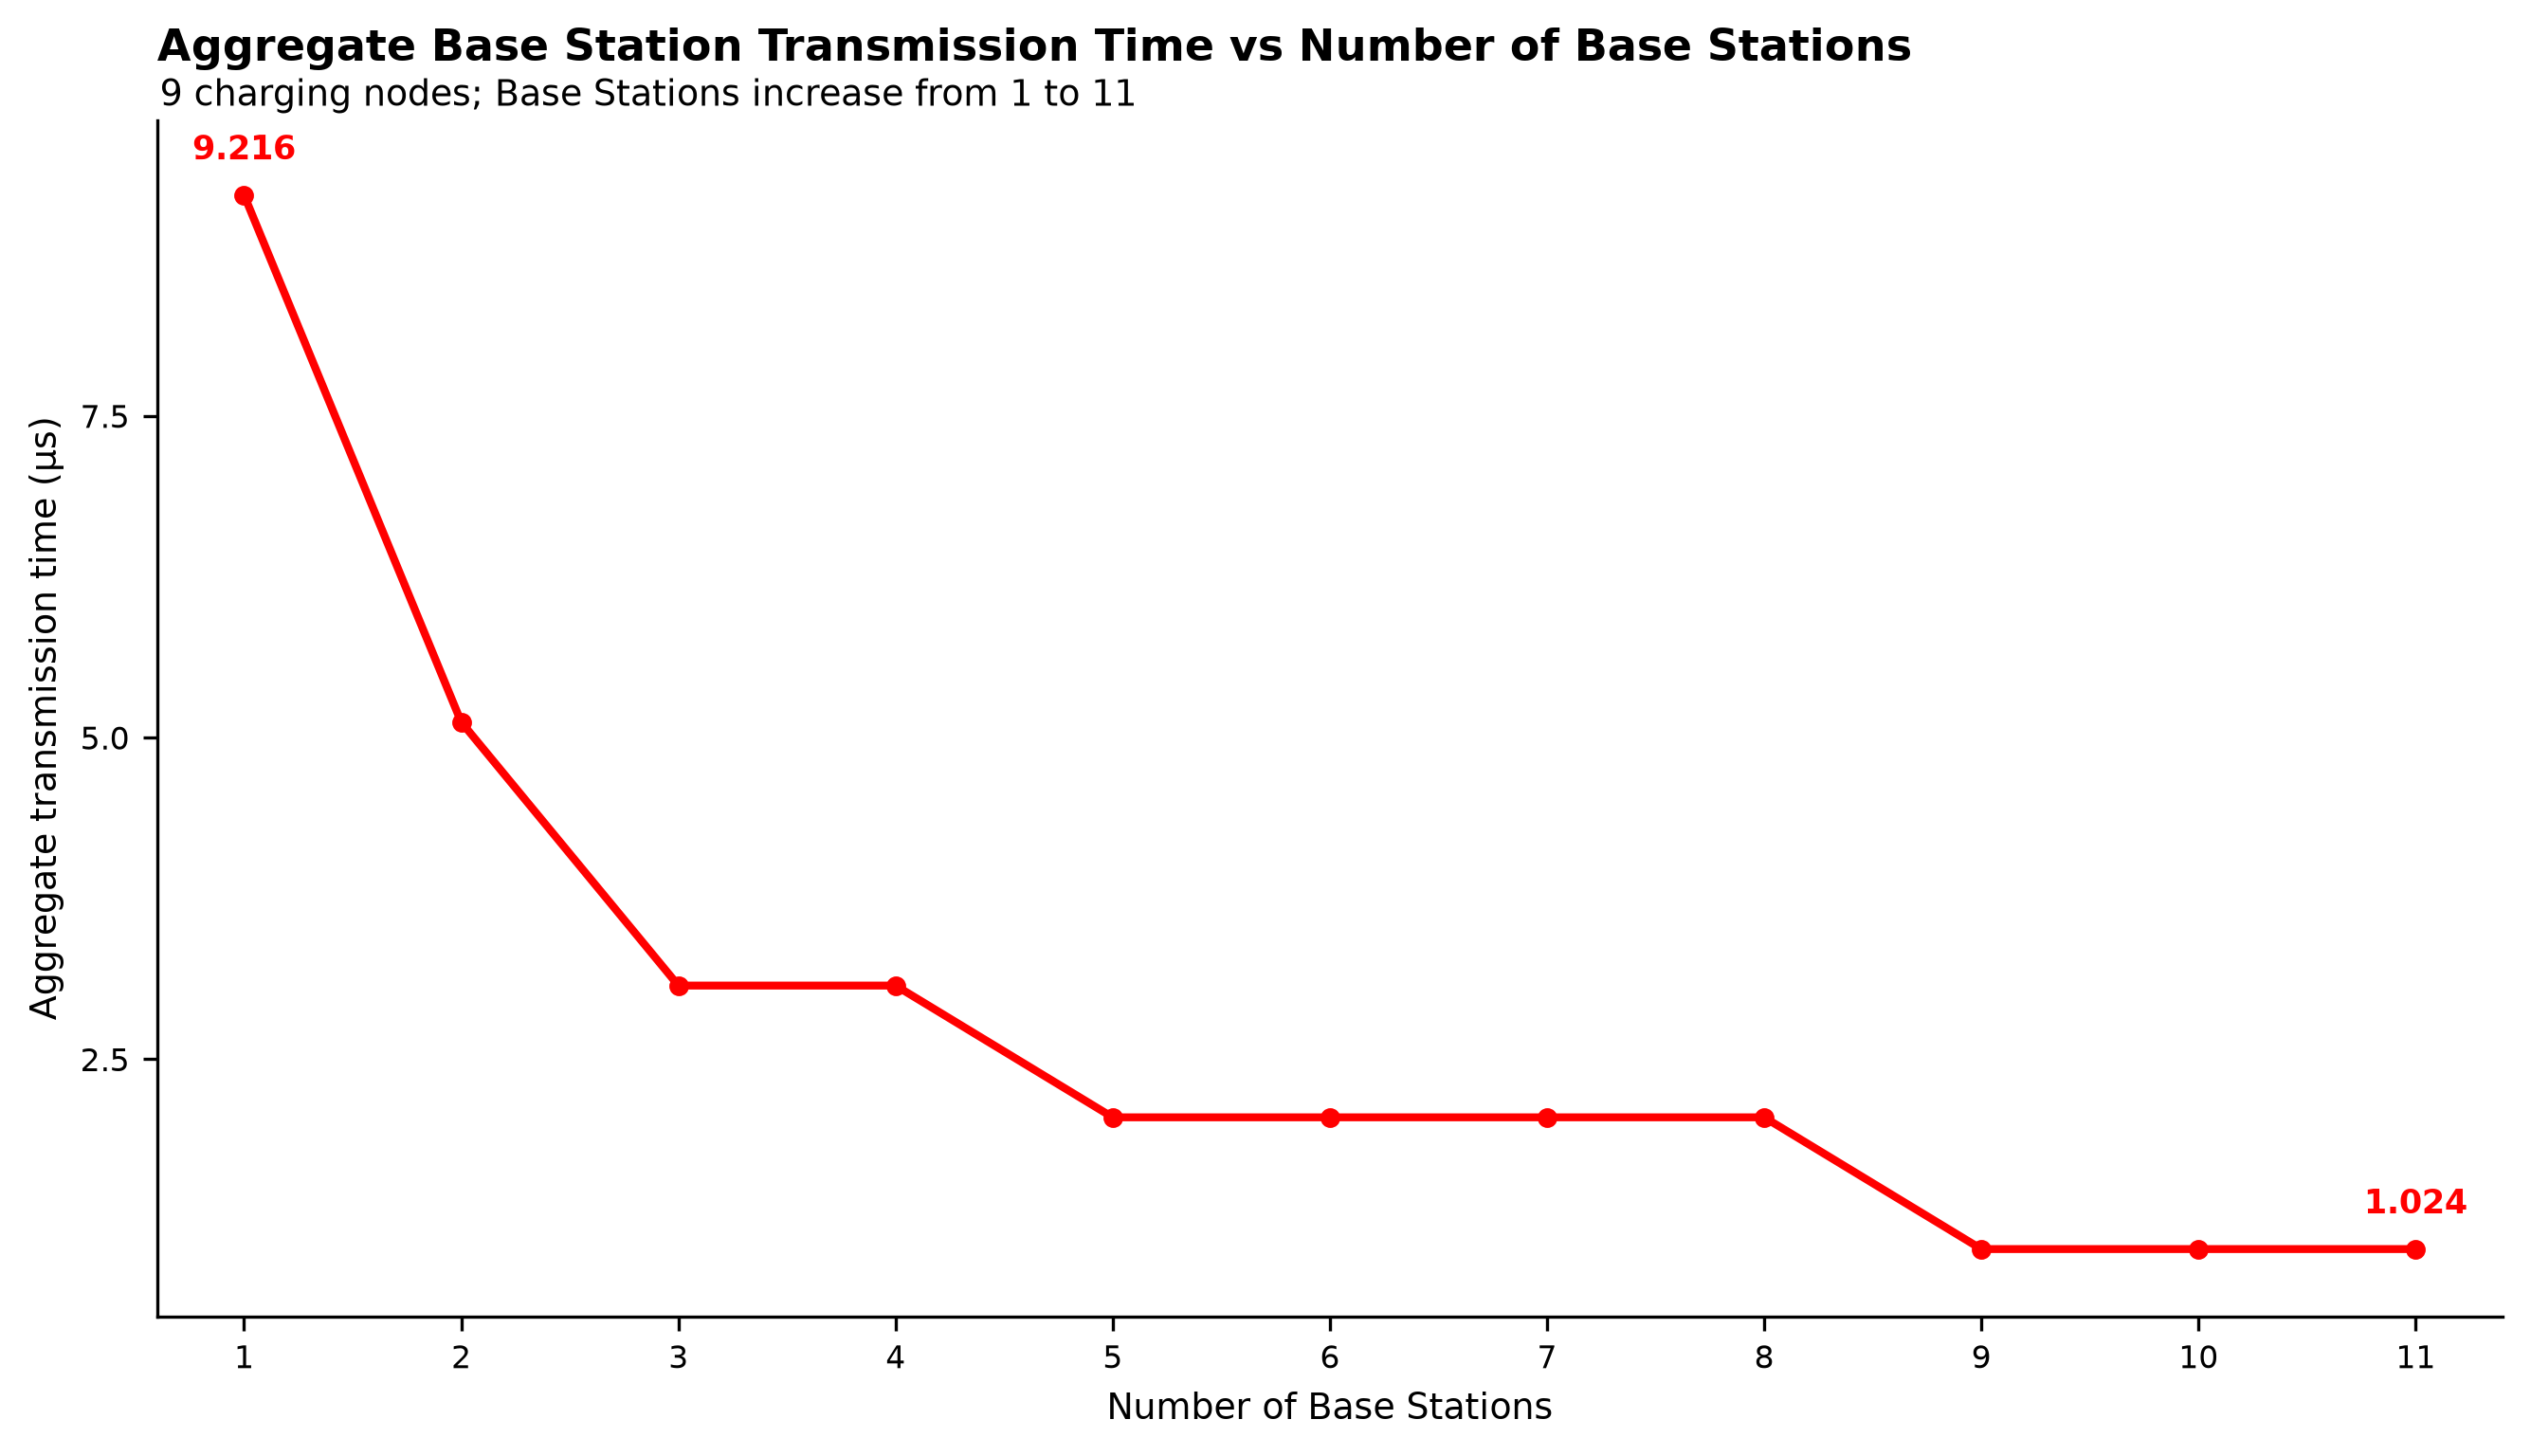

In [18]:
import matplotlib.pyplot as plt
import numpy as np

n_nodes = 9
t_base = 0.512 * 2 
base_stations = np.arange(1, 12)

max_packets_per_bs = np.ceil(n_nodes / base_stations)
agg_transmission_time = max_packets_per_bs * t_base

plt.figure(figsize=(9, 5.5), dpi=300)
plt.plot(
    base_stations,
    agg_transmission_time,
    color="red",
    marker="o",
    linewidth=2,
    markersize=4,
)

plt.title(
    "Aggregate Base Station Transmission Time vs Number of Base Stations",
    fontsize=11,
    fontweight="bold",
    loc="left",
    pad=15,
)
plt.suptitle(
    "9 charging nodes; Base Stations increase from 1 to 11",
    fontsize=9,
    x=0.068,
    y=0.89,
    ha="left",
)

target_indices = [0, -1]
for i in target_indices:
  x = base_stations[i]
  y = agg_transmission_time[i]
  plt.annotate(
      f"{y:.3f}",
      xy=(x, y),
      xytext=(0, 7),
      textcoords="offset points",
      ha="center",
      va="bottom",
      fontsize=8.5,
      fontweight="bold",
      color='red',  # 与折线颜色一致
  )

plt.xlabel("Number of Base Stations", fontsize=9)
plt.ylabel("Aggregate transmission time (μs)", fontsize=9)

plt.xticks(np.arange(1, 12), fontsize=8)
plt.yticks([2.5, 5.0, 7.5], fontsize=8)
plt.ylim(0.5, 9.8)
plt.xlim(0.6, 11.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

plt.tight_layout()
plt.savefig('graph1_transmission_delay.png', dpi=300, bbox_inches='tight')
plt.show()

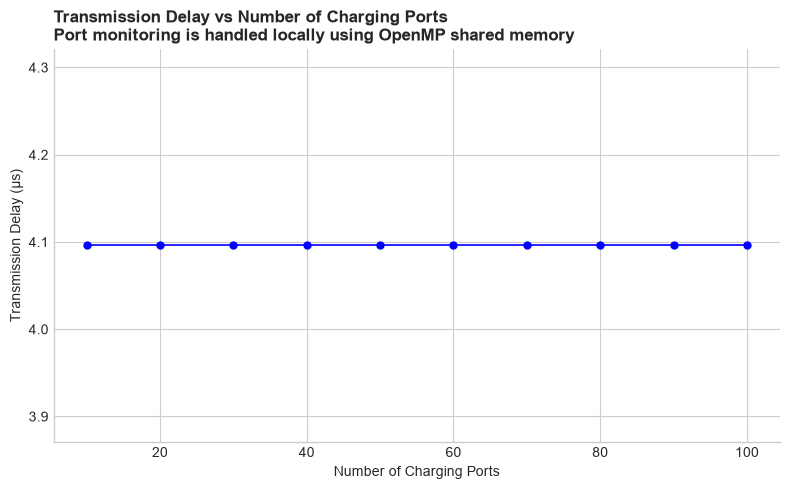

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Number of charging ports
ports = list(range(10, 110, 10))

# Network transmission delay remains constant
# because port monitoring is local using OpenMP shared memory
transmission_delay = [4.096] * len(ports)

data = pd.DataFrame({"ports": ports, "transmission_delay": transmission_delay})

# Plot configuration
plt.style.use("seaborn-v0_8-whitegrid")  # replicates theme_minimal()
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    data["ports"],
    data["transmission_delay"],
    color="blue",
    linewidth=1.2,
    marker="o",
    markersize=5,
)

# Labels and title
ax.set_title(
    "Transmission Delay vs Number of Charging Ports\n"
    "Port monitoring is handled locally using OpenMP shared memory",
    fontsize=12,
    fontweight="bold",
    loc="left",
)
ax.set_xlabel("Number of Charging Ports")
ax.set_ylabel("Transmission Delay (μs)")

# Despine top and right to match ggplot's minimal styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()